<a href="https://colab.research.google.com/github/omaryasser1907/FOOD-1O1-classification/blob/main/FOOD_101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CUSTOM DATASET



In [5]:
import torch
from torch import nn
device="cuda" if torch.cuda.is_available () else "cpu"
device


'cuda'

In [6]:
from pathlib import Path
import requests
import zipfile
data_path=Path("data/")
image_path=data_path/"pizza_steak_sushi"
if image_path.is_dir():
  print(f"{image_path} is here ,skip downloading " )
else:
  print(f"{image_path} is not here , so start downloading")
  image_path.mkdir(parents=True,exist_ok=True)

with open(data_path/"pizza_steak_sushi.zip","wb")as f:
  request=requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi.zip")
  f.write(request.content)
with zipfile.ZipFile(data_path/"pizza_steak_sushi.zip","r")as zip_ref:
  print(f"unzipping zip file ")
  zip_ref.extractall(image_path)

data/pizza_steak_sushi is not here , so start downloading
unzipping zip file 


In [7]:
# walking through the data
import os
def walk_through_data (dir_path):
  for dirpath,dirnames,filenames in os.walk(dir_path):
    print(f"there are {len(dirnames)} :directories and {len(filenames)}: images in {dirpath} folder")

In [8]:
walk_through_data(image_path)

there are 2 :directories and 0: images in data/pizza_steak_sushi folder
there are 3 :directories and 0: images in data/pizza_steak_sushi/test folder
there are 0 :directories and 31: images in data/pizza_steak_sushi/test/sushi folder
there are 0 :directories and 19: images in data/pizza_steak_sushi/test/steak folder
there are 0 :directories and 25: images in data/pizza_steak_sushi/test/pizza folder
there are 3 :directories and 0: images in data/pizza_steak_sushi/train folder
there are 0 :directories and 72: images in data/pizza_steak_sushi/train/sushi folder
there are 0 :directories and 75: images in data/pizza_steak_sushi/train/steak folder
there are 0 :directories and 78: images in data/pizza_steak_sushi/train/pizza folder


In [9]:
# setting train & test directories
train_dir=image_path/"train"
test_dir=image_path/"test"
train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [10]:
# visualizing images
import random
from PIL import Image
random.seed(42)
image_path_list=list(image_path.glob("*/*/*.jpg"))
random_image=random.choice(image_path_list)
image_class=random_image.parent.stem
img=Image.open(random_image)
# printing all metadata
print(f"random image choice : {random_image}")
print(f"random image class : {image_class}")
print(f"random image height : {img.height}")
print(f"random image width : {img.width}")
#img

random image choice : data/pizza_steak_sushi/test/pizza/2508636.jpg
random image class : pizza
random image height : 512
random image width : 512


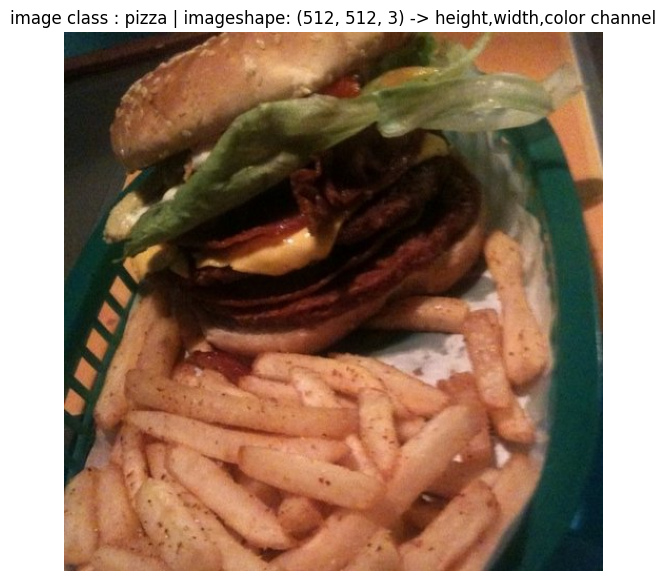

In [11]:
# matplot visualizing
import numpy as np
import matplotlib.pyplot as plt
img_as_array=np.asarray(img)
# plotting
plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"image class : {image_class} | imageshape: {img_as_array.shape} -> height,width,color channel")
plt.axis(False) ;

In [12]:
!pip install torchvision

In [13]:
from torch.utils.data import DataLoader
from torchvision import transforms,datasets
data_transforms=transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])


In [14]:
data_transforms(img).shape

torch.Size([3, 64, 64])

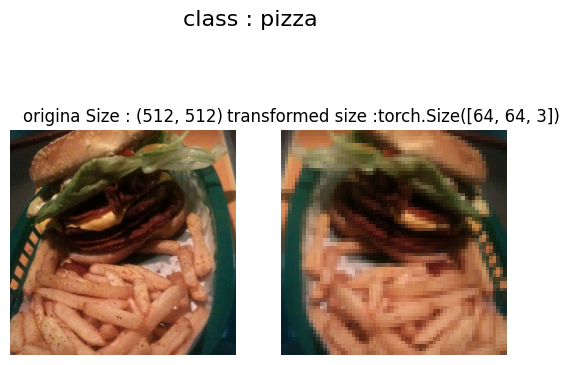

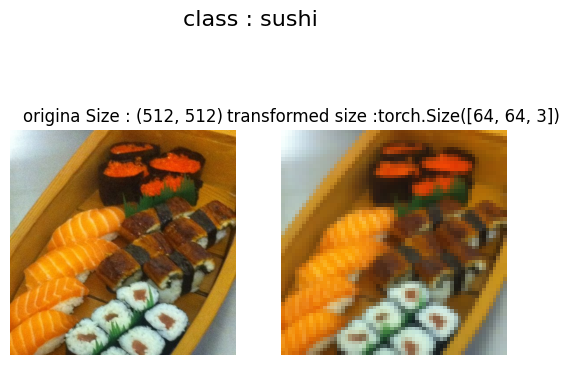

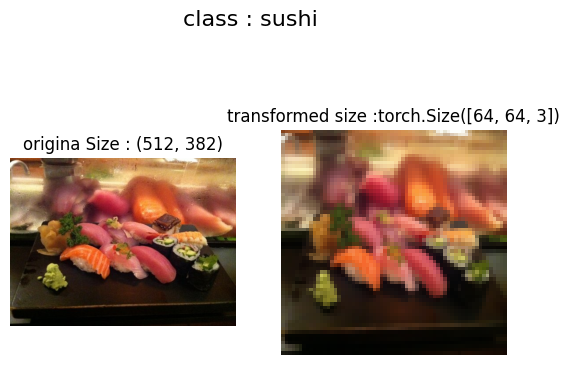

In [15]:
# plotting original vs transformed images
def plot_transformed_image (image_paths:list,
                            transform,
                            n=3,
                            seed=None):
  if seed :
    random.seed(seed)
  random_image_paths=random.sample(image_path_list,k=n)
  for image_path in (random_image_paths):
    with Image.open(image_path)as f :
      fig,ax=plt.subplots(nrows=1,ncols=2)
      ax[0].imshow(f)
      ax[0].set_title(f"origina Size : {f.size}")
      ax[0].axis(False)
      transformed_image=transform(f).permute(1,2,0)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"transformed size :{transformed_image.shape}")
      ax[1].axis(False)
      fig.suptitle(f"class : {image_path.parent.stem}",fontsize=16 )
plot_transformed_image(image_paths=image_path_list,
                       transform=data_transforms,
                       n=3,
                       seed=42)



In [16]:
## loading data using ImageFolder
from torchvision import datasets
train_data=datasets.ImageFolder(root=train_dir,
                                transform=data_transforms,
                                target_transform=None)
test_data=datasets.ImageFolder(root=test_dir,
                                transform=data_transforms,
                                target_transform=None)


In [17]:
train_data,test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [18]:
class_names=train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [19]:
# creating classes dictionary
classes_dict=train_data.class_to_idx
classes_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [20]:
len(train_data),len(test_data)

(225, 75)

In [21]:
# indexing one image and label to work on
img,label=train_data[0][0],train_data[0][1]
print(f"image tensor :\n {img}")
print(f"image shape : {img.shape }")
print(f"image type : {img.dtype}")
print(f"image label : {label}")
print(f"label data type : {type(label)}")


image tensor :
 tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.

 original img shape : torch.Size([3, 64, 64])
 permuted img shape : torch.Size([64, 64, 3])


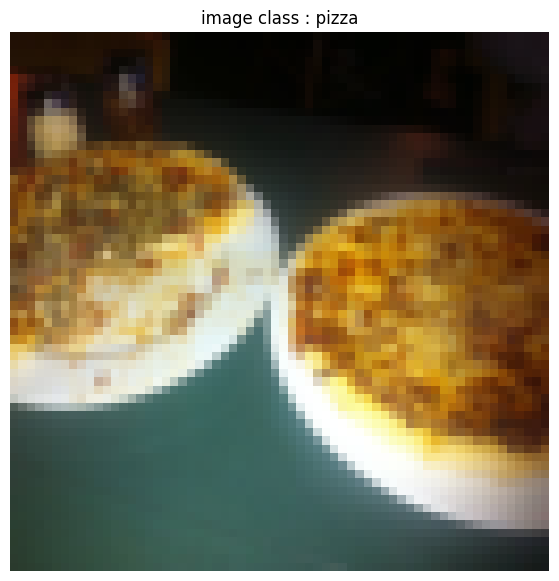

In [22]:
# plotting the selected image
img_permute=img.permute(1,2,0)

plt.figure(figsize=(10,7))
plt.imshow(img_permute)
plt.axis(False)
plt.title(f"image class : {class_names[label]}")
# printing original shape vs permuted shape
print(f" original img shape : {img.shape}")
print(f" permuted img shape : {img_permute.shape}")

## let's create DATALOADER


In [23]:
from torch.utils.data import DataLoader
BATCHSIZE=32
train_dataloader=DataLoader(dataset=train_data,
                            batch_size=BATCHSIZE,
                            num_workers=1,
                            shuffle=True)
test_dataloader=DataLoader(dataset=test_data ,
                           batch_size=BATCHSIZE,
                           num_workers=1,
                           shuffle=None)
train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7b81a0229010>,
 <torch.utils.data.dataloader.DataLoader at 0x7b817ec10410>)

In [24]:
len(train_dataloader),len(test_dataloader)

(8, 3)

In [25]:
len(train_data),len(test_data)

(225, 75)

In [26]:
## adding batch size dim on our img
img,label=next(iter(train_dataloader))
print(f"image shape : {img.shape} -> [batch_size,color_channel,height,width]")
print(f"label shape : {label.shape}")

image shape : torch.Size([32, 3, 64, 64]) -> [batch_size,color_channel,height,width]
label shape : torch.Size([32])


In [27]:
# augentations using TrivialAugmenWide
from torchvision import transforms
train_transform=transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])
test_transform=transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ToTensor()
])

In [28]:
image_path

PosixPath('data/pizza_steak_sushi')

In [29]:
image_path_list=list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[PosixPath('data/pizza_steak_sushi/test/sushi/1742201.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/1987407.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/479711.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/3177743.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/887831.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/988559.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/3196729.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/1230335.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/2715127.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/1600999.jpg')]

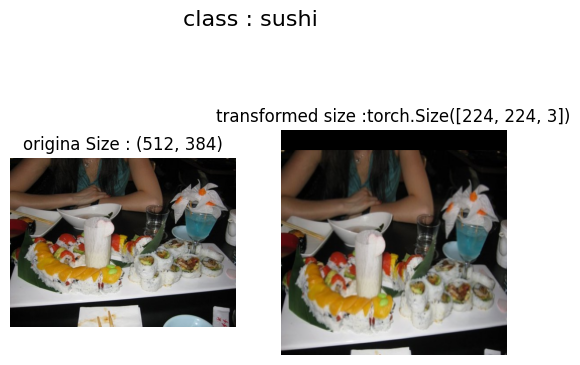

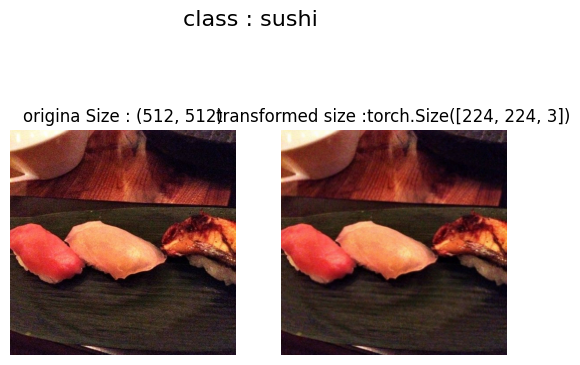

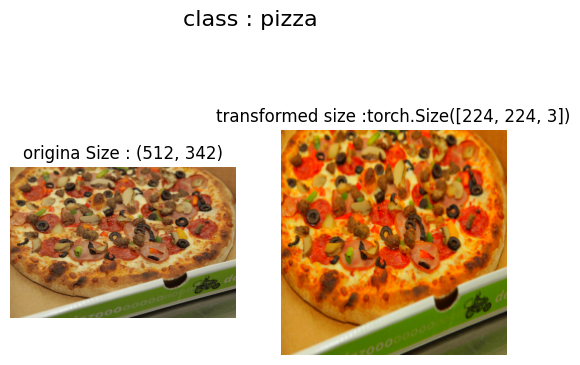

In [30]:
# let's plot
plot_transformed_image(image_paths=image_path_list,
                       transform=train_transform,
                       n=3,
                       seed=None)

## model using TINY VGG

In [37]:
## CREATING AND LOADING DATA FOR FIRST MODEL
from torchvision import transforms
simple_transform= transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()

])

In [38]:
from torchvision import datasets
train_data_model0=datasets.ImageFolder(
    root=train_dir,
    transform=simple_transform,
    target_transform=None
)
test_data_model0= datasets.ImageFolder(
    root=test_dir,
    transform=simple_transform,
    target_transform=None
)



In [39]:
# datsets to dataloader
from torch.utils.data import DataLoader
BATCH_SIZE=32
train_dataloader_model0=DataLoader(
    dataset=train_data_model0,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=os.cpu_count()
)
test_dataloader_model0=DataLoader(
    dataset=test_data_model0,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=os.cpu_count()
)


In [40]:
len(train_dataloader_model0),len(test_dataloader_model0)

(8, 3)